In [ ]:
# install kaggle
!pip install -q kaggle

In [ ]:
import os
import kagglehub
from google.colab import userdata

# 1. Mengambil API Token dari Colab Secrets
try:
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
except Exception:
    print("Saran: Masukkan KAGGLE_API_TOKEN ke dalam Secrets di Google Colab untuk keamanan.")

# 2. Mengunduh dataset kompetisi
path = kagglehub.competition_download('triagegeist')

print("Path to competition files:", path)
print("Files downloaded:", os.listdir(path))

100%|██████████| 8.96M/8.96M [00:00<00:00, 11.1MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/triagegeist
Files downloaded: ['NOTE.md', 'sample_submission.csv', 'train.csv', 'chief_complaints.csv', 'patient_history.csv', 'test.csv']


In [ ]:
import pandas as pd

# 1. Load data utama (train dan test)
df_train = pd.read_csv(f"{path}/train.csv")
df_test = pd.read_csv(f"{path}/test.csv")

# 2. Load data pendukung/tambahan
df_history = pd.read_csv(f"{path}/patient_history.csv")
df_complaints = pd.read_csv(f"{path}/chief_complaints.csv")
df_sample_sub = pd.read_csv(f"{path}/sample_submission.csv")

# Menampilkan informasi dasar dan ukuran data train
print("Ukuran Data Train:", df_train.shape)
print("\nInformasi Data Train:")
print(df_train.info())

# Menampilkan 5 baris pertama data train
df_train.head()

Ukuran Data Train: (80000, 40)

Informasi Data Train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                80000 non-null  object 
 1   site_id                   80000 non-null  object 
 2   triage_nurse_id           80000 non-null  object 
 3   arrival_mode              80000 non-null  object 
 4   arrival_hour              80000 non-null  int64  
 5   arrival_day               80000 non-null  object 
 6   arrival_month             80000 non-null  int64  
 7   arrival_season            80000 non-null  object 
 8   shift                     80000 non-null  object 
 9   age                       80000 non-null  int64  
 10  age_group                 80000 non-null  object 
 11  sex                       80000 non-null  object 
 12  language                  80000 non-null  object 
 13  insuran

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3


In [ ]:
# 1. Definisi kolom yang digunakan sesuai batas hardware
used_cols = [
    'temperature_c', 'spo2', 'respiratory_rate',
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'gcs_total'
]
target_col = 'triage_acuity'

# 2. Validasi keberadaan kolom
missing_train = [col for col in used_cols + [target_col] if col not in df_train.columns]
missing_test = [col for col in used_cols if col not in df_test.columns]

assert not missing_train, f"Kolom hilang di df_train: {missing_train}"
assert not missing_test, f"Kolom hilang di df_test: {missing_test}"

# 3. Filtering data
train = df_train[used_cols + [target_col]].copy()
test = df_test[used_cols].copy()

print(f"Bentuk train: {train.shape} | Bentuk test: {test.shape}")
train.head()

Bentuk train: (80000, 8) | Bentuk test: (20000, 7)


,temperature_c,spo2,respiratory_rate,heart_rate,systolic_bp,diastolic_bp,gcs_total,triage_acuity
0,37.0,92.1,17.9,57.3,79.0,57.5,14,2
1,36.9,99.4,17.2,97.3,131.7,93.4,15,5
2,37.3,100.0,14.7,75.6,94.7,83.3,15,5
3,38.2,96.0,17.6,109.0,134.2,51.8,15,3
4,36.6,99.1,17.6,113.7,140.1,75.4,15,3


In [ ]:
import pandas as pd

# 1. Definisi Mapping Langsung: ESI (1-5) -> Kode Numerik CTM (0, 1, 2)
# 0: Resuscitation (ESI 1)
# 1: Urgent (ESI 2 & 3)
# 2: Non-Urgent (ESI 4 & 5)
ctm_mapping = {
    1: 0,
    2: 1,
    3: 1,
    4: 2,
    5: 2
}

# 2. Konversi ESI langsung ke Target CTM
train['target'] = train['triage_acuity'].map(ctm_mapping)

# 3. Defensive Check: Memastikan tidak ada nilai NaN/outlier pada kolom target
assert train['target'].isnull().sum() == 0, "ERROR: Ditemukan nilai triage_acuity di luar rentang 1-5!"

# 4. Hapus kolom triage_acuity secara eksplisit
train = train.drop(columns=['triage_acuity', 'ctm_label'], errors='ignore')

# 5. Verifikasi Distribusi Kelas & Struktur Data Akhir
print("=== DISTRIBUSI KELAS TARGET CTM ===")
print("0 (Resuscitation) :", (train['target'] == 0).sum())
print("1 (Urgent)        :", (train['target'] == 1).sum())
print("2 (Non-Urgent)    :", (train['target'] == 2).sum())

print("\nUkuran Data Train Saat Ini:", train.shape)
print("Daftar Kolom Sisa:", list(train.columns))

train.head()

=== DISTRIBUSI KELAS TARGET CTM ===
0 (Resuscitation) : 3222
1 (Urgent)        : 42360
2 (Non-Urgent)    : 34418

Ukuran Data Train Saat Ini: (80000, 8)
Daftar Kolom Sisa: ['temperature_c', 'spo2', 'respiratory_rate', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'gcs_total', 'target']


,temperature_c,spo2,respiratory_rate,heart_rate,systolic_bp,diastolic_bp,gcs_total,target
0,37.0,92.1,17.9,57.3,79.0,57.5,14,1
1,36.9,99.4,17.2,97.3,131.7,93.4,15,2
2,37.3,100.0,14.7,75.6,94.7,83.3,15,2
3,38.2,96.0,17.6,109.0,134.2,51.8,15,1
4,36.6,99.1,17.6,113.7,140.1,75.4,15,1


In [ ]:
# 1. Identifikasi Fitur (X) dan Target (y)
feature_cols = [c for c in train.columns if c != 'target']

# 2. Cek Conflicting Labels (Fitur X sama persis, tapi Target y Berbeda)
conflicting_mask = train.duplicated(subset=feature_cols, keep=False) & ~train.duplicated(subset=feature_cols + ['target'], keep=False)
num_conflicts = conflicting_mask.sum()

if num_conflicts > 0:
    print(f"[PERINGATAN] Ditemukan {num_conflicts} baris data dengan fitur vital sign sama persis TETAPI target CTM berbeda!")
    # Strategi: Hapus data bertentangan ini agar tidak membingungkan model XGBoost
    train = train[~conflicting_mask].copy()

# 3. Hapus Duplikat Persis (Fitur X sama DAN Target y sama)
duplicated_sum = train.duplicated().sum()
if duplicated_sum > 0:
    train = train.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"Duplikat persis berhasil dihapus: {duplicated_sum} baris.")
else:
    train = train.reset_index(drop=True)
    print("Tidak ada duplikat persis.")

print(f"Ukuran Data Train Setelah Cleaning: {train.shape}")
train.head()

Duplikat persis berhasil dihapus: 1 baris.
Ukuran Data Train Setelah Cleaning: (79999, 8)


,temperature_c,spo2,respiratory_rate,heart_rate,systolic_bp,diastolic_bp,gcs_total,target
0,37.0,92.1,17.9,57.3,79.0,57.5,14,1
1,36.9,99.4,17.2,97.3,131.7,93.4,15,2
2,37.3,100.0,14.7,75.6,94.7,83.3,15,2
3,38.2,96.0,17.6,109.0,134.2,51.8,15,1
4,36.6,99.1,17.6,113.7,140.1,75.4,15,1


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Isolasi Fitur (X) dan Target (y)
X = train.drop(columns=['target'])
y = train['target']

# 2. Pembagian Data Latih dan Validasi (80:20) dengan Stratifikasi
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Verifikasi Ukuran Dataset & Proporsi Kelas Target
print("=== DIMENSI SUBSET DATA ===")
print(f"Data Latih (X_train, y_train): {X_train.shape} | {y_train.shape}")
print(f"Data Validasi (X_val, y_val) : {X_val.shape} | {y_val.shape}\n")

print("=== DISTRIBUSI KELAS TARGET (STRATIFIED %) ===")
print("Data Latih (%):\n", (y_train.value_counts(normalize=True) * 100).round(2).to_dict())
print("Data Validative (%):\n", (y_val.value_counts(normalize=True) * 100).round(2).to_dict())

=== DIMENSI SUBSET DATA ===
Data Latih (X_train, y_train): (63999, 7) | (63999,)
Data Validasi (X_val, y_val) : (16000, 7) | (16000,)

=== DISTRIBUSI KELAS TARGET (STRATIFIED %) ===
Data Latih (%):
 {1: 52.95, 2: 43.02, 0: 4.03}
Data Validative (%):
 {1: 52.95, 2: 43.03, 0: 4.03}


In [ ]:
# 1. Identifikasi kolom yang memiliki missing values secara dinamis dari X_train
cols_with_na = X_train.columns[X_train.isnull().any()].tolist()

print(f"Kolom dengan missing values yang terdeteksi: {cols_with_na}")

# 2. Hitung median HANYA dari X_train untuk mencegah Data Leakage
train_medians = X_train[cols_with_na].median()

# 3. Imputasi X_train dan X_val menggunakan median dari X_train
X_train[cols_with_na] = X_train[cols_with_na].fillna(train_medians)
X_val[cols_with_na] = X_val[cols_with_na].fillna(train_medians)

# 4. Verifikasi konfirmasi
assert X_train.isnull().sum().sum() == 0, "Masih ada missing value di X_train!"
assert X_val.isnull().sum().sum() == 0, "Masih ada missing value di X_val!"

print("Imputasi median berhasil. Seluruh missing values di X_train dan X_val telah ditangani tanpa menghapus baris.")

Kolom dengan missing values yang terdeteksi: ['temperature_c', 'respiratory_rate', 'systolic_bp', 'diastolic_bp']
Imputasi median berhasil. Seluruh missing values di X_train dan X_val telah ditangani tanpa menghapus baris.


In [ ]:
def clip_physiological_outliers(df):
    df = df.copy()
    # Batas fisiologis manusia hidup yang realistis
    df['spo2'] = df['spo2'].clip(upper=100.0, lower=50.0)
    df['temperature_c'] = df['temperature_c'].clip(upper=43.0, lower=30.0)
    df['systolic_bp'] = df['systolic_bp'].clip(upper=260.0, lower=40.0)
    df['diastolic_bp'] = df['diastolic_bp'].clip(upper=160.0, lower=20.0)
    df['heart_rate'] = df['heart_rate'].clip(upper=230.0, lower=20.0)
    df['respiratory_rate'] = df['respiratory_rate'].clip(upper=60.0, lower=4.0)
    df['gcs_total'] = df['gcs_total'].clip(upper=15, lower=3)
    return df

# Terapkan secara terpisah pada train dan val
X_train = clip_physiological_outliers(X_train)
X_val = clip_physiological_outliers(X_val)

In [ ]:
import numpy as np
def calculate_news_subscore(df):
    """
    Menghitung sub-skor NEWS (0-3 per vital sign) berdasarkan ambang batas internasional.
    """
    # 1. Respiratory Rate
    rr = df['respiratory_rate']
    rr_score = np.select(
        [rr <= 8, (rr >= 9) & (rr <= 11), (rr >= 12) & (rr <= 20), (rr >= 21) & (rr <= 24), rr >= 25],
        [3, 1, 0, 2, 3], default=0
    )

    # 2. SpO2
    spo2 = df['spo2']
    spo2_score = np.select(
        [spo2 <= 91, (spo2 >= 92) & (spo2 <= 93), (spo2 >= 94) & (spo2 <= 95), spo2 >= 96],
        [3, 2, 1, 0], default=0
    )

    # 3. Systolic BP
    sbp = df['systolic_bp']
    sbp_score = np.select(
        [sbp <= 90, (sbp >= 91) & (sbp <= 100), (sbp >= 101) & (sbp <= 110), (sbp >= 111) & (sbp <= 219), sbp >= 220],
        [3, 2, 1, 0, 3], default=0
    )

    # 4. Heart Rate
    hr = df['heart_rate']
    hr_score = np.select(
        [hr <= 40, (hr >= 41) & (hr <= 50), (hr >= 51) & (hr <= 90), (hr >= 91) & (hr <= 110), (hr >= 111) & (hr <= 130), hr >= 131],
        [3, 1, 0, 1, 2, 3], default=0
    )

    # 5. Temperature
    temp = df['temperature_c']
    temp_score = np.select(
        [temp <= 35.0, (temp >= 35.1) & (temp <= 36.0), (temp >= 36.1) & (temp <= 38.0), (temp >= 38.1) & (temp <= 39.0), temp >= 39.1],
        [3, 1, 0, 1, 2], default=0
    )

    # 6. GCS
    gcs = df['gcs_total']
    gcs_score = np.select(
        [gcs == 15, (gcs >= 13) & (gcs <= 14), (gcs >= 9) & (gcs <= 12), gcs <= 8],
        [0, 1, 2, 3], default=0
    )

    return rr_score + spo2_score + sbp_score + hr_score + temp_score + gcs_score

def feature_engineering(df_features):
    df = df_features.copy()

    # --- 1. RASIO HEMODINAMIK ---
    df['shock_index'] = df['heart_rate'] / (df['systolic_bp'] + 0.1)
    df['mean_arterial_pressure'] = df['diastolic_bp'] + (1/3 * (df['systolic_bp'] - df['diastolic_bp']))
    df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
    df['modified_shock_index'] = df['heart_rate'] / (df['mean_arterial_pressure'] + 0.1)

    # --- 2. FITUR GRADEN KEPARAHAN KONTINU (Menggantikan Flag Biner) ---
    df['temp_deviation'] = (df['temperature_c'] - 37.0).abs()
    df['oxygen_deficit'] = (98.0 - df['spo2']).clip(lower=0.0)
    df['gcs_deficit'] = 15 - df['gcs_total']

    # --- 3. FITUR INTERAKSI ANTA-SISTEM ORGAN ---
    df['cardiopulmonary_stress'] = (df['heart_rate'] * df['respiratory_rate']) / 100.0
    df['neuro_hemodynamic_index'] = df['shock_index'] * (df['gcs_deficit'] + 1)

    # --- 4. SKOR RISKO AGREGAT (NEWS-ADAPTED) ---
    df['news_vital_score'] = calculate_news_subscore(df)

    return df

X_train = feature_engineering(X_train)
X_val = feature_engineering(X_val)

print(f"Bentuk X_train setelah feature engineering: {X_train.shape}")
print(f"Bentuk X_val setelah feature engineering: {X_val.shape}")
X_train.head()

Bentuk X_train setelah feature engineering: (63999, 17)
Bentuk X_val setelah feature engineering: (16000, 17)


,temperature_c,spo2,respiratory_rate,heart_rate,systolic_bp,diastolic_bp,gcs_total,shock_index,mean_arterial_pressure,pulse_pressure,modified_shock_index,temp_deviation,oxygen_deficit,gcs_deficit,cardiopulmonary_stress,neuro_hemodynamic_index,news_vital_score
72730,38.1,93.5,21.2,83.3,110.5,88.2,15,0.753165,95.633333,22.3,0.870125,1.1,4.5,0,17.6596,0.753165,3
16802,37.2,95.4,14.3,70.5,123.1,75.3,15,0.572240,91.233333,47.8,0.771898,0.2,2.6,0,10.0815,0.572240,0
59150,36.3,95.3,19.9,74.5,125.1,77.9,15,0.595048,93.633333,47.2,0.794808,0.7,2.7,0,14.8255,0.595048,0
53132,37.0,93.6,21.8,100.2,106.7,83.7,15,0.938202,91.366667,23.0,1.095481,0.0,4.4,0,21.8436,0.938202,4
22325,36.6,97.0,12.5,100.9,110.1,77.4,15,0.915608,88.300000,32.7,1.141403,0.4,1.0,0,12.6125,0.915608,1


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Hitung Sample Weight untuk Penyeimbangan Kelas
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Inisialisasi Baseline Model XGBoost
baseline_model = XGBClassifier(
    objective='multi:softprob',
    random_state=42,
    eval_metric='mlogloss'
)

# 3. Latih Model menggunakan Data Fisiologis Asli (Tanpa Scaling)
baseline_model.fit(X_train, y_train, sample_weight=sample_weights_train)

# 4. Prediksi Prediksi Label & Probabilitas pada Data Validasi
y_pred_base = baseline_model.predict(X_val)
y_pred_base_proba = baseline_model.predict_proba(X_val)

# 5. Evaluasi Baseline Model
base_accuracy = accuracy_score(y_val, y_pred_base)
base_f1_macro = f1_score(y_val, y_pred_base, average='macro')

print("=== PERFORMA BASELINE MODEL XGBOOST ===")
print(f"Accuracy : {base_accuracy:.4f}")
print(f"F1-Macro : {base_f1_macro:.4f}\n")

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_val, y_pred_base, target_names=['Resuscitation (0)', 'Urgent (1)', 'Non-Urgent (2)']))

print("--- CONFUSION MATRIX ---")
print(confusion_matrix(y_val, y_pred_base))

=== PERFORMA BASELINE MODEL XGBOOST ===
Accuracy : 0.8766
F1-Macro : 0.8851

--- CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

Resuscitation (0)       0.87      0.94      0.91       644
       Urgent (1)       0.91      0.85      0.88      8472
   Non-Urgent (2)       0.84      0.90      0.87      6884

         accuracy                           0.88     16000
        macro avg       0.87      0.90      0.89     16000
     weighted avg       0.88      0.88      0.88     16000

--- CONFUSION MATRIX ---
[[ 608   36    0]
 [  91 7221 1160]
 [   0  688 6196]]


In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 21.0 MB/s eta 0:00:00


In [ ]:
# import optuna
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import f1_score
# from sklearn.utils.class_weight import compute_sample_weight
# import numpy as np

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective(trial):
#     params = {
#         'objective': 'multi:softprob',
#         'random_state': 42,
#         'eval_metric': 'mlogloss',
#         'n_estimators': trial.suggest_int('n_estimators', 100, 800),
#         'max_depth': trial.suggest_int('max_depth', 3, 8),  # Batasi kedalaman agar tidak overfit
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
#         'gamma': trial.suggest_float('gamma', 0.0, 5.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
#     }

#     # Gunakan 5-Fold CV HANYA pada X_train untuk mencegah Validation Leakage
#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     cv_scores = []

#     for train_idx, val_idx in skf.split(X_train, y_train):
#         X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
#         y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

#         sw_tr = compute_sample_weight(class_weight='balanced', y=y_tr)

#         model = XGBClassifier(**params)
#         model.fit(X_tr, y_tr, sample_weight=sw_tr)

#         preds = model.predict(X_va)
#         score = f1_score(y_va, preds, average='macro')
#         cv_scores.append(score)

#     return np.mean(cv_scores)

# # Buat study Optuna
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print("\nHyperparameter Tuning (5-Fold CV) Selesai!")
# print("Parameter Terbaik:", study.best_params)
# print(f"Skor F1-Macro CV Terbaik: {study.best_value:.4f}")

In [ ]:
# {'n_estimators': 387, 'max_depth': 7, 'learning_rate': 0.022996218635452717, 'subsample': 0.9755898036774517, 'colsample_bytree': 0.6438649673762407, 'min_child_weight': 6, 'gamma': 0.7376391591478958, 'reg_alpha': 1.3000185882592977e-06, 'reg_lambda': 5.3826209898796826e-05}

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Ambil Parameter Terbaik dari Optuna & Inisialisasi Final Model
best_params = {'n_estimators': 387, 'max_depth': 7, 'learning_rate': 0.022996218635452717, 'subsample': 0.9755898036774517, 'colsample_bytree': 0.6438649673762407, 'min_child_weight': 6, 'gamma': 0.7376391591478958, 'reg_alpha': 1.3000185882592977e-06, 'reg_lambda': 5.3826209898796826e-05}
final_model = XGBClassifier(**best_params)

# 2. Hitung Sample Weight untuk Seluruh Set Latih
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

# 3. Latih Final Model pada 100% Data Latih (X_train)
final_model.fit(X_train, y_train, sample_weight=sample_weights_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

# 4. Prediksi pada Hold-Out Validation Set (X_val)
y_pred_final = final_model.predict(X_val)
y_pred_final_proba = final_model.predict_proba(X_val)

# 5. Hitung Metrik Evaluasi Final
final_acc = accuracy_score(y_val, y_pred_final)
final_f1_macro = f1_score(y_val, y_pred_final, average='macro')

# 6. Tabel Komparasi Baseline vs Final Model pada Data Validasi (X_val)
delta_f1 = ((final_f1_macro - base_f1_macro) / base_f1_macro) * 100

print("="*60)
print("     EVALUASI INDEPENDEN PADA HOLD-OUT VALIDATION SET (X_val)     ")
print("="*60)
df_eval = pd.DataFrame({
    'Model': ['XGBoost Baseline', 'XGBoost Final (Tuned)'],
    'Accuracy': [f"{base_accuracy:.4f}", f"{final_acc:.4f}"],
    'F1-Macro': [f"{base_f1_macro:.4f}", f"{final_f1_macro:.4f}"]
})
print(df_eval.to_string(index=False))
print(f"\Peningkatan F1-Macro setelah Tuning & Feature Engineering: {delta_f1:+.2f}%\n")

# 7. Classification Report Detail
print("--- FINAL MODEL CLASSIFICATION REPORT ---")
print(classification_report(
    y_val, y_pred_final,
    target_names=['Resuscitation (0)', 'Urgent (1)', 'Non-Urgent (2)']
))

# 8. Confusion Matrix Detail
print("--- FINAL MODEL CONFUSION MATRIX ---")
cm = confusion_matrix(y_val, y_pred_final)
cm_df = pd.DataFrame(
    cm,
    index=['Actual Resuscitation', 'Actual Urgent', 'Actual Non-Urgent'],
    columns=['Pred Resuscitation', 'Pred Urgent', 'Pred Non-Urgent']
)
print(cm_df)

<>:36: SyntaxWarning: invalid escape sequence '\P'
<>:36: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_2093/3858875714.py:36: SyntaxWarning: invalid escape sequence '\P'
  print(f"\Peningkatan F1-Macro setelah Tuning & Feature Engineering: {delta_f1:+.2f}%\n")


     EVALUASI INDEPENDEN PADA HOLD-OUT VALIDATION SET (X_val)     
                Model Accuracy F1-Macro
     XGBoost Baseline   0.8766   0.8851
XGBoost Final (Tuned)   0.8743   0.8745
\Peningkatan F1-Macro setelah Tuning & Feature Engineering: -1.20%

--- FINAL MODEL CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

Resuscitation (0)       0.80      0.96      0.88       644
       Urgent (1)       0.91      0.84      0.88      8472
   Non-Urgent (2)       0.84      0.91      0.87      6884

         accuracy                           0.87     16000
        macro avg       0.85      0.90      0.87     16000
     weighted avg       0.88      0.87      0.87     16000

--- FINAL MODEL CONFUSION MATRIX ---
                      Pred Resuscitation  Pred Urgent  Pred Non-Urgent
Actual Resuscitation                 621           23                0
Actual Urgent                        154         7137             1181
Actual Non-Urgent                    

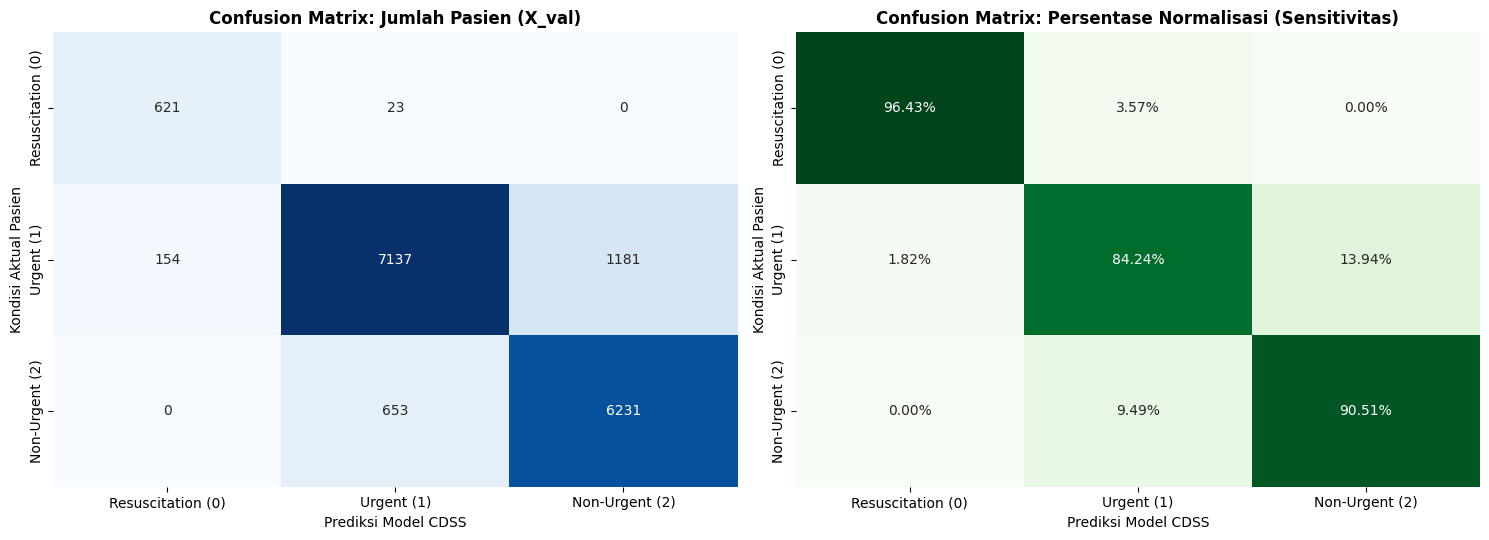

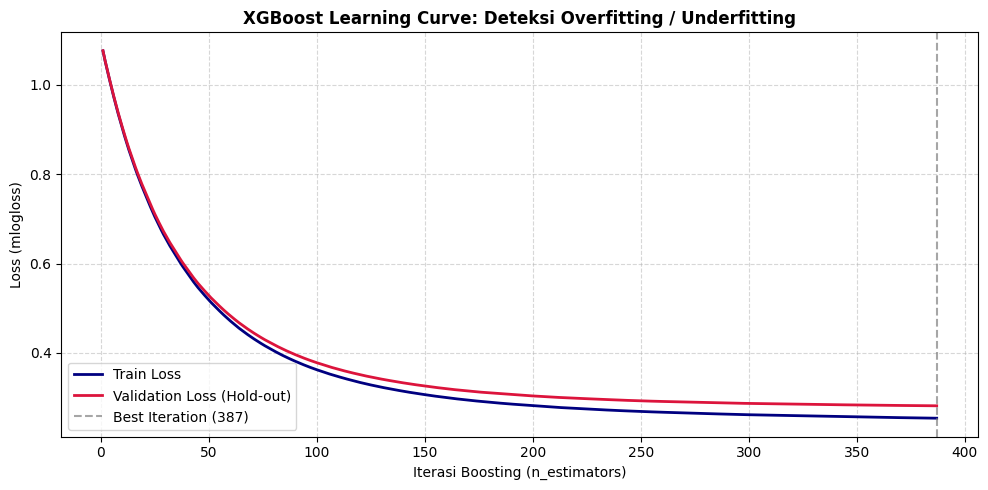

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Definisi Label Kelas CTM
class_names = ['Resuscitation (0)', 'Urgent (1)', 'Non-Urgent (2)']

# 2. Kalkulasi Confusion Matrix Raw Count & Normalized
cm_raw = confusion_matrix(y_val, y_pred_final)
cm_norm = confusion_matrix(y_val, y_pred_final, normalize='true')

# 3. Visualisasi Confusion Matrix (Dual Panel Side-by-Side)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel A: Raw Count (Jumlah Pasien)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[0].set_title('Confusion Matrix: Jumlah Pasien (X_val)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model CDSS', fontsize=10)
axes[0].set_ylabel('Kondisi Aktual Pasien', fontsize=10)

# Panel B: Normalized (Persentase per Kelas Aktual - Sensitivitas)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[1].set_title('Confusion Matrix: Persentase Normalisasi (Sensitivitas)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model CDSS', fontsize=10)
axes[1].set_ylabel('Kondisi Aktual Pasien', fontsize=10)

plt.tight_layout()
plt.show()

# 4. Visualisasi Learning Curve (Train vs Validation Loss)
evals_result = final_model.evals_result()

if evals_result and 'validation_0' in evals_result:
    # Mengambil log loss untuk train dan validation
    metric_key = list(evals_result['validation_0'].keys())[0]
    train_loss = evals_result['validation_0'][metric_key]
    val_loss = evals_result['validation_1'][metric_key]
    epochs = len(train_loss)

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), train_loss, label='Train Loss', color='navy', linewidth=2)
    plt.plot(range(1, epochs + 1), val_loss, label='Validation Loss (Hold-out)', color='crimson', linewidth=2)

    # Menandai titik Validation Loss minimum
    min_val_idx = np.argmin(val_loss) + 1
    min_val_loss = np.min(val_loss)
    plt.axvline(x=min_val_idx, color='gray', linestyle='--', alpha=0.7, label=f'Best Iteration ({min_val_idx})')

    plt.title('XGBoost Learning Curve: Deteksi Overfitting / Underfitting', fontsize=12, fontweight='bold')
    plt.xlabel('Iterasi Boosting (n_estimators)', fontsize=10)
    plt.ylabel(f'Loss ({metric_key})', fontsize=10)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
df_test.head()

,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score
0,TG-FZUFCRZS3,SITE-TMP-01,NURSE-0050,walk-in,7,Monday,4,spring,morning,24,...,26.7,38.5,88.8,10,10,86.9,177.2,27.7,1.032,13
1,TG-SSCOXTYI1,SITE-TMP-01,NURSE-0001,ambulance,17,Monday,3,spring,afternoon,53,...,20.6,38.9,100.0,15,9,67.0,156.2,27.5,0.827,4
2,TG-JY74ZR35D,SITE-HEL-01,NURSE-0018,ambulance,2,Monday,1,winter,night,88,...,27.7,38.8,94.7,14,6,76.3,149.4,34.2,0.694,9
3,TG-JDKD5G62X,SITE-TUR-01,NURSE-0028,walk-in,23,Saturday,3,spring,evening,59,...,14.9,36.3,99.0,15,4,103.8,172.4,35.0,0.572,0
4,TG-J1BSAAXR0,SITE-TMP-01,NURSE-0033,helicopter,16,Saturday,6,summer,afternoon,44,...,15.2,37.6,100.0,15,1,76.7,168.5,27.0,NaN,0


In [ ]:
!pip install -q onnxruntime onnxmltools skl2onnx onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 56.7 MB/s eta 0:00:00


In [ ]:
# ==========================================
# CELL 28: XGBoost Model to ONNX Conversion & Verification (FIXED FEATURE NAMES)
# ==========================================
import os
import warnings
import numpy as np
import pandas as pd
import onnxruntime as rt

from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# Sembunyikan warning deprecation agar konsol bersih
warnings.filterwarnings('ignore')

print("📦 Mempersiapkan Konversi Model XGBoost Triage ke Format ONNX...")

# Path direktori di Google Drive
output_dir = '/content/drive/MyDrive/TriaGO_Project/Model_Artifacts'
os.makedirs(output_dir, exist_ok=True)
onnx_filename = os.path.join(output_dir, 'triage_xgboost_model.onnx')

# 1. Tentukan Input Spec (Jumlah Fitur)
n_features = X_train.shape[1]
initial_type = [('float_input', FloatTensorType([None, n_features]))]

# 2. Hapus Sementara Atribut Feature Names dari Model XGBoost
# Hal ini wajib dilakukan agar parser onnxmltools tidak error membaca nama kolom string seperti 'gcs_total'
booster = final_model.get_booster()
original_feature_names = booster.feature_names
booster.feature_names = None

try:
    # 3. Konversi Model XGBoost ke ONNX
    onnx_model = convert_xgboost(
        final_model,
        initial_types=initial_type,
        target_opset=13
    )

    # 4. Simpan File ONNX ke Drive
    with open(onnx_filename, "wb") as f:
        f.write(onnx_model.SerializeToString())

    size_kb = os.path.getsize(onnx_filename) / 1024
    print(f"📄 Model XGBoost ONNX tersimpan: {onnx_filename} ({size_kb:.2f} KB)")

finally:
    # Kembalikan feature_names asli ke model agar tidak mengganggu variabel Python di memori
    booster.feature_names = original_feature_names

# ==============================================================================
# 5. VERIFIKASI INFERENSI ONNX VS XGBOOST ORIGINAL
# ==============================================================================
print("\n=== UJI COBA INFERENSI ONNX VS ORIGINAL ===")

sample_idx = 0
X_sample_raw = X_val.iloc[[sample_idx]] if isinstance(X_val, pd.DataFrame) else X_val[[sample_idx]]
X_sample_onnx = X_sample_raw.values.astype(np.float32)

# A. Jalankan ONNX Runtime CPU
sess = rt.InferenceSession(onnx_filename, providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name

onnx_outputs = sess.run(None, {input_name: X_sample_onnx})

if len(onnx_outputs) > 1:
    raw_prob = onnx_outputs[1]
else:
    raw_prob = onnx_outputs[0]

if isinstance(raw_prob, list) and isinstance(raw_prob[0], dict):
    prob_vec = np.array(list(raw_prob[0].values()))
else:
    prob_vec = np.squeeze(np.array(raw_prob))

pred_onnx = int(np.argmax(prob_vec))

# B. Jalankan XGBoost Original
prob_orig = final_model.predict_proba(X_sample_raw)[0]
pred_orig = final_model.predict(X_sample_raw)[0]

ctm_decode = {0: 'Resuscitation', 1: 'Urgent', 2: 'Non-Urgent'}

print("="*60)
print(f"Prediksi XGBoost Original : {ctm_decode[pred_orig]} (Prob: {prob_orig[pred_orig]:.4f})")
print(f"Prediksi ONNX Runtime CPU : {ctm_decode[pred_onnx]} (Prob: {prob_vec[pred_onnx]:.4f})")

if pred_orig == pred_onnx and np.allclose(prob_orig, prob_vec, atol=1e-4):
    print("\n🟢 VERIFIKASI BERHASIL: Hasil ONNX 100% identik dengan XGBoost Original!")
    print(f"   File '{os.path.basename(onnx_filename)}' SIAP DIPINDAHKAN ke Raspberry Pi 5.")
else:
    print("\n🔴 VERIFIKASI GAGAL: Terdapat perbedaan hasil antara ONNX dan Original.")

📦 Mempersiapkan Konversi Model XGBoost Triage ke Format ONNX...
📄 Model XGBoost ONNX tersimpan: /content/drive/MyDrive/TriaGO_Project/Model_Artifacts/triage_xgboost_model.onnx (2661.22 KB)

=== UJI COBA INFERENSI ONNX VS ORIGINAL ===
Prediksi XGBoost Original : Urgent (Prob: 0.9956)
Prediksi ONNX Runtime CPU : Urgent (Prob: 0.9956)

🟢 VERIFIKASI BERHASIL: Hasil ONNX 100% identik dengan XGBoost Original!
   File 'triage_xgboost_model.onnx' SIAP DIPINDAHKAN ke Raspberry Pi 5.


In [ ]:
from google.colab import files

# Download langsung file ONNX XGBoost ke komputer
files.download('/content/drive/MyDrive/TriaGO_Project/Model_Artifacts/triage_xgboost_model.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>